In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import HDBSCAN
import astropy.units as u
# from zero_point import zpt
from tqdm import tqdm

In [189]:
df = pd.read_csv("dataset_100pc(in).csv")
df["parallax_"] = df["parallax"]/1000

In [190]:
df.columns

Index(['Unnamed: 0', 'source_id', 'ra', 'dec', 'parallax', 'pmra', 'pmdec',
       'ruwe', 'phot_g_mean_mag', 'bp_rp', 'radial_velocity', 'ra_error',
       'dec_error', 'pmra_error', 'pmdec_error', 'parallax_error',
       'visibility_periods_used', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
       'nu_eff_used_in_astrometry', 'pseudocolour', 'ecl_lat',
       'astrometric_params_solved', 'zp', 'fidelity_v2', 'parallax_'],
      dtype='str')

In [ ]:
df["relative_error"] = df["parallax"]/df["parallax_error"]
print(df.shape)

(574531, 27)


In [ ]:
df = df[df["relative_error"]<0.1]
df.shape

(372226, 27)

In [193]:
hyades_ra = 66.75
hyades_dec = 15.867
hyades_dist = 46 
hyades_deg_window = 15
hyades_parallax_window = 20


hyades_conditions = (1/(hyades_dist+hyades_parallax_window) <= df["parallax_"]) & (df["parallax_"] <= 1/(hyades_dist-hyades_parallax_window)) & ((hyades_dec-hyades_deg_window) <= df["dec"]) & (df["dec"] <= hyades_dec+hyades_deg_window) & (hyades_ra-hyades_deg_window <= df["ra"]) & (df["ra"] <= hyades_ra+hyades_deg_window)

hyades_df = df[hyades_conditions]

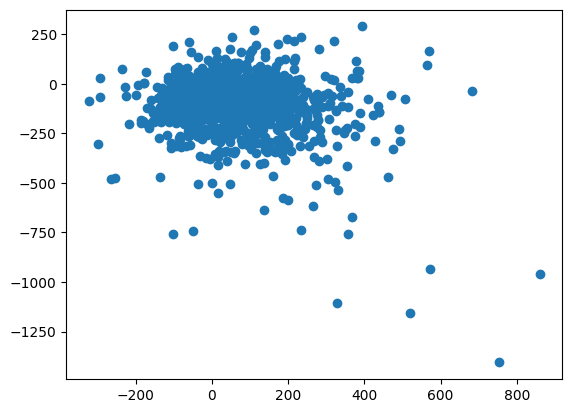

In [194]:
plt.scatter(hyades_df["pmra"], hyades_df["pmdec"])

In [195]:
hyades_df.shape[0]

2415

HDBSCAN

In [196]:
clustering_on = ["pmra", "pmdec", "parallax"]

In [197]:
hyades_data = hyades_df[clustering_on]
hyades_data = RobustScaler().fit_transform(hyades_data)

In [198]:
hd_hyades = HDBSCAN(min_cluster_size=53, min_samples=5, metric='euclidean').fit(hyades_data)

In [199]:
labels_hyades = hd_hyades.labels_ 
hyades_df['label_hb'] = labels_hyades
for i in list(set(labels_hyades)):
    print('{} {}'.format(i,len(hyades_df[(hyades_df['label_hb'] == i)])))

0 53
1 339
-1 2023


In [200]:
hyades_df['label_hb'] = hyades_df['label_hb'].replace(1, 0)

In [201]:
labels_hyades[labels_hyades == 1] = 0

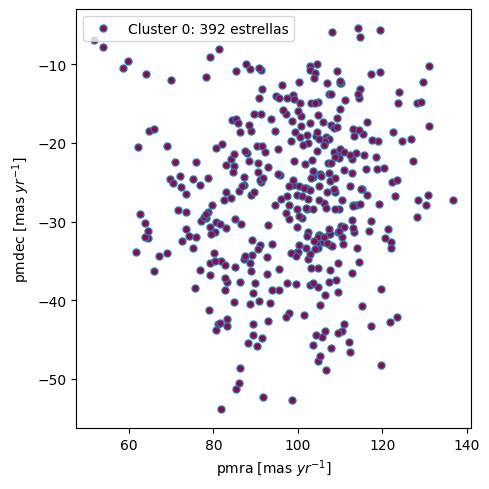

In [202]:
unique_labels = set(labels_hyades)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(5,5))
for i, j in zip(list(unique_labels), colors):
    if i != -1:
        condition = (hyades_df['label_hb'] == i)
        plt.plot(hyades_df['pmra'][condition], hyades_df['pmdec'][condition], 
         markerfacecolor = tuple(j),marker = 'o', linestyle='None',markersize = 5, alpha = 1,label=f"Cluster {i}: {hyades_df[condition].shape[0]} estrellas")
plt.xlabel("pmra [mas $yr^{-1}$]")
plt.ylabel("pmdec [mas $yr^{-1}$]")
plt.tight_layout()
plt.legend()
plt.show() 

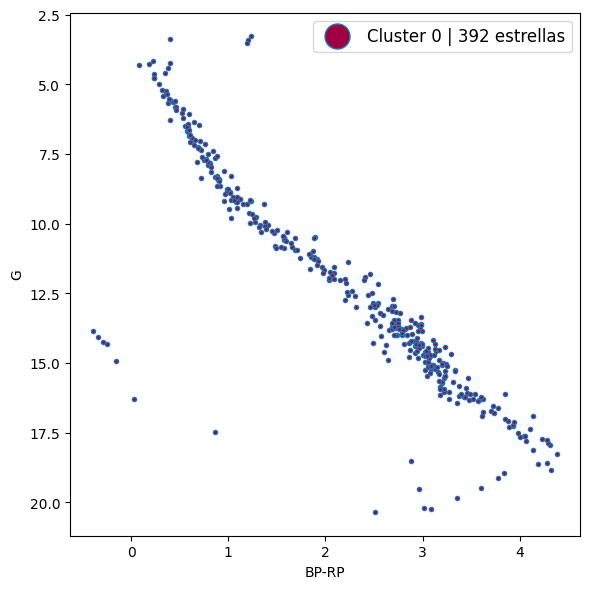

In [203]:
fig, ax = plt.subplots(figsize=(6,6))

for i, j in zip(list(unique_labels), colors):

    if i != -1:
    #if True:
        condition = (hyades_df['label_hb'] == i)

        ax.plot(
            hyades_df['phot_bp_mean_mag'][condition] - hyades_df['phot_rp_mean_mag'][condition],
            hyades_df['phot_g_mean_mag'][condition],
            marker='o',
            linestyle='None',
            markersize=3,
            markerfacecolor=tuple(j),
            label=f'Cluster {i} | {len(hyades_df[condition])} estrellas'
        )

ax.set_xlabel("BP-RP")
ax.set_ylabel("G")
ax.invert_yaxis()

ax.legend(markerscale=6, fontsize=12)

plt.tight_layout()
plt.show()

In [204]:
coma_ra = 185.625
coma_dec = 25.85
coma_dist = 86 
coma_deg_window = 15
coma_parallax_window = 20


coma_conditions = (1/(coma_dist+coma_parallax_window) <= df["parallax_"]) & (df["parallax_"] <= 1/(coma_dist-coma_parallax_window)) & ((coma_dec-coma_deg_window) <= df["dec"]) & (df["dec"] <= coma_dec+coma_deg_window) & (coma_ra-coma_deg_window <= df["ra"]) & (df["ra"] <= coma_ra+coma_deg_window)

coma_df = df[coma_conditions]

In [205]:
coma_data = coma_df[clustering_on]
coma_data = RobustScaler().fit_transform(coma_data)

In [206]:
hd_coma = HDBSCAN(min_cluster_size=50, min_samples=10, metric='euclidean').fit(coma_data)

In [207]:
labels_coma = hd_coma.labels_ 
coma_df['label_hb'] = labels_coma
for i in list(set(labels_coma)):
    print('{} {}'.format(i,len(coma_df[(coma_df['label_hb'] == i)])))

0 212
1 345
-1 3384


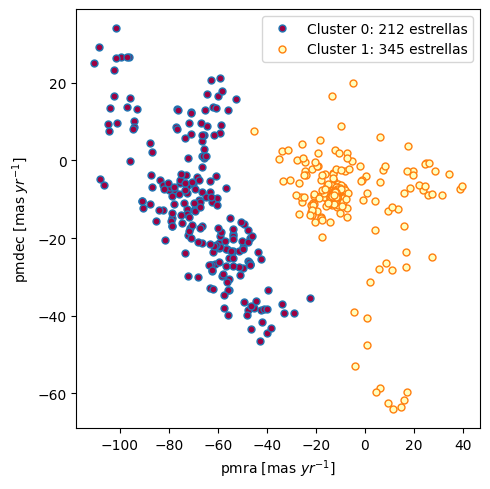

In [208]:
unique_labels = set(labels_coma)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(5,5))
for i, j in zip(list(unique_labels), colors):
    if i != -1:
        condition = (coma_df['label_hb'] == i)
        plt.plot(coma_df['pmra'][condition], coma_df['pmdec'][condition], 
         markerfacecolor = tuple(j),marker = 'o', linestyle='None',markersize = 5, alpha = 1,label=f"Cluster {i}: {coma_df[condition].shape[0]} estrellas")
plt.xlabel("pmra [mas $yr^{-1}$]")
plt.ylabel("pmdec [mas $yr^{-1}$]")
plt.tight_layout()
plt.legend()
plt.show() 

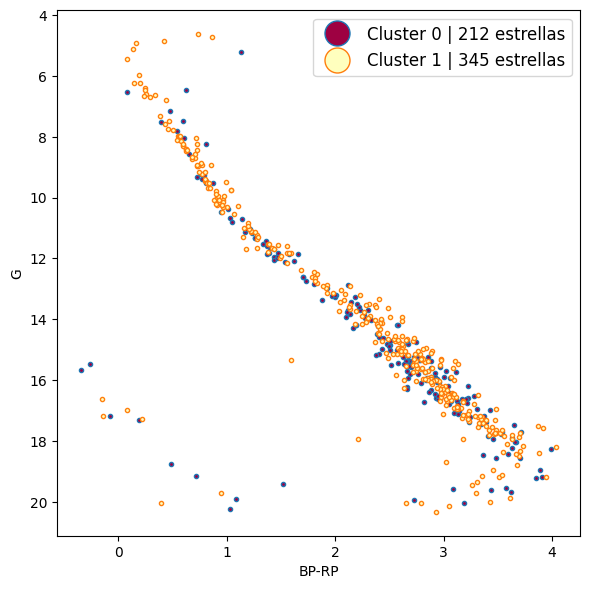

In [209]:
fig, ax = plt.subplots(figsize=(6,6))

for i, j in zip(list(unique_labels), colors):

    if i != -1:
    #if True:
        condition = (coma_df['label_hb'] == i)

        ax.plot(
            coma_df['phot_bp_mean_mag'][condition] - coma_df['phot_rp_mean_mag'][condition],
            coma_df['phot_g_mean_mag'][condition],
            marker='o',
            linestyle='None',
            markersize=3,
            markerfacecolor=tuple(j),
            label=f'Cluster {i} | {len(coma_df[condition])} estrellas'
        )

ax.set_xlabel("BP-RP")
ax.set_ylabel("G")
ax.invert_yaxis()

ax.legend(markerscale=6, fontsize=12)

plt.tight_layout()
plt.show()

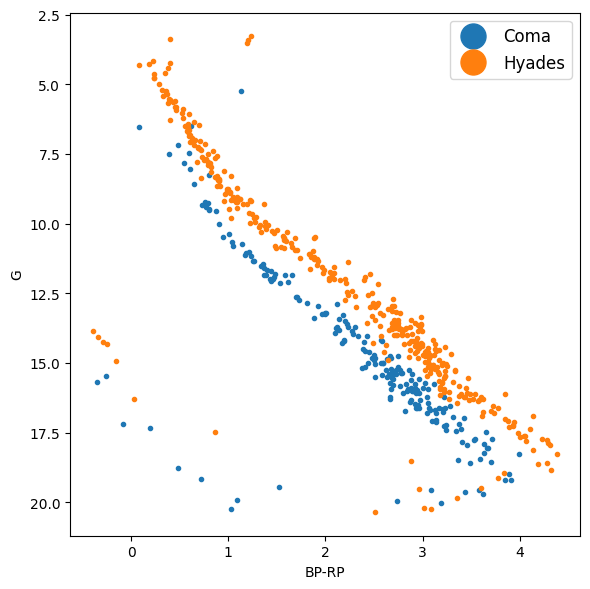

In [210]:
hyades_cluster = hyades_df[hyades_df['label_hb'] == 0]
coma_cluster = coma_df[coma_df['label_hb'] == 0]

fig, ax = plt.subplots(figsize=(6,6))

ax.plot(
            coma_cluster['phot_bp_mean_mag'] - coma_cluster['phot_rp_mean_mag'],
            coma_cluster['phot_g_mean_mag'],
            marker='o',
            linestyle='None',
            markersize=3,
            label=f'Coma'
        )

ax.plot(
            hyades_cluster['phot_bp_mean_mag'] - hyades_cluster['phot_rp_mean_mag'],
            hyades_cluster['phot_g_mean_mag'],
            marker='o',
            linestyle='None',
            markersize=3,
            label=f'Hyades'
        )

ax.set_xlabel("BP-RP")
ax.set_ylabel("G")
ax.invert_yaxis()

ax.legend(markerscale=6, fontsize=12)

plt.tight_layout()
plt.show()

In [211]:
print(df.shape)
cluster_mask = (hyades_conditions | coma_conditions)
df = df[~cluster_mask]
print(df.shape)

(372226, 27)
(365870, 27)


In [212]:
# Crear bins de la grilla 8x8
ra_bins = np.linspace(df["ra"].min(), df["ra"].max(), 9)
dec_bins = np.linspace(df["dec"].min(), df["dec"].max(), 9)

df["grid_i"] = np.digitize(df["ra"], ra_bins) - 1
df["grid_j"] = np.digitize(df["dec"], dec_bins) - 1

# Clip para evitar índices fuera de rango en los bordes
df["grid_i"] = df["grid_i"].clip(0, 7)
df["grid_j"] = df["grid_j"].clip(0, 7)

df["cell_id"] = df["grid_i"] * 8 + df["grid_j"] + 1  # 1 a 64

df = df.drop(columns=["grid_i", "grid_j"])

In [213]:
df.to_csv("dataset_porcionado.csv")